In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
class Logistic_Regression():
  def __init__(self, learning_rate = 0.01, epochs = 1000):
    self.learning_rate = learning_rate
    self.epochs = epochs
    self.w = None
    self.b = None
    self.loss_history = [] # To store loss at each epoch

  def _sigmoid(self, z):
    # More numerically stable sigmoid implementation
    z = np.clip(z, -500, 500) # Clip values to prevent overflow
    return 1 / (1 + np.exp(-z))

  def fit(self, X, Y):
    self.m , self.n = X.shape

    #Storing X and Y
    self.X = X
    self.Y = Y

    #Initializing weights and biases

    self.w = np.zeros(self.n)
    self.b = 0

    #Optimization Loop
    for i in range(self.epochs):
      self.update_weights()
      loss = self._calculate_loss() # Calculate and store loss
      self.loss_history.append(loss)


  def update_weights(self):

    #Prediction

    linear = self.X.dot(self.w) + self.b
    Y_hat = self._sigmoid(linear)

    #Derivatives

    dw = (1/self.m) * np.dot(self.X.T, (Y_hat - self.Y))
    db = (1/self.m) * np.sum(Y_hat - self.Y)

    #Gradient Descent

    self.w -= self.learning_rate * dw
    self.b -= self.learning_rate * db

  def _calculate_loss(self):
    linear = self.X.dot(self.w) + self.b
    Y_hat = self._sigmoid(linear)
    # Using a small epsilon to avoid log(0)
    epsilon = 1e-15
    loss = -np.mean(self.Y * np.log(Y_hat + epsilon) + (1 - self.Y) * np.log(1 - Y_hat + epsilon))
    return loss


  def predict(self, X):

    #Predict on unseen data

    linear = X.dot(self.w) + self.b
    Y_pred = self._sigmoid(linear)
    Y_pred = np.where(Y_pred > 0.5, 1, 0)
    return Y_pred

In [ ]:
#Load Dataset

df = pd.read_csv('framingham.csv')
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## Target Variable

    10 year risk of coronary heart disease CHD:
    (Binary) The desired target. "1" means "Yes", and "0" means "No".

## Predictor Features

Demographic

    Sex: (Nominal) male or female.

    Age: (Continuous) Age of the patient. Although recorded as whole numbers, the concept of age is continuous.

    Education: (Nominal/Ordinal) The patient's highest level of education.
      1.0: Some High School
      2.0: High School or GED
      3.0: Some College or Vocational School
      4.0: College (Bachelor's degree or higher)

Behavioral

    Current Smoker: (Nominal) Whether or not the patient is a current smoker.

    Cigs Per Day: (Continuous) The number of cigarettes that the person smoked on average in one day.

Medical (History)

    BP Meds: (Nominal) Whether or not the patient was on blood pressure medication.

    Prevalent Stroke: (Nominal) Whether or not the patient had previously had a stroke.

    Prevalent Hyp: (Nominal) Whether or not the patient was hypertensive.

    Diabetes: (Nominal) Whether or not the patient had diabetes.

Medical (Current)

    Tot Chol: (Continuous) Total cholesterol level.

    Sys BP: (Continuous) Systolic blood pressure.

    Dia BP: (Continuous) Diastolic blood pressure.

    BMI: (Continuous) Body Mass Index.

    Heart Rate: (Continuous) Heart rate. Considered continuous due to the large number of possible values.

    Glucose: (Continuous) Glucose level.

In [ ]:
df.shape

(4238, 16)

In [ ]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [ ]:
df.isnull().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [ ]:
df['education'].fillna(df['education'].mode()[0], inplace=True)
df['cigsPerDay'].fillna(df['cigsPerDay'].median(), inplace=True)
df['BPMeds'].fillna(df['BPMeds'].mode()[0], inplace=True)
df['totChol'].fillna(df['totChol'].median(), inplace=True)
df['BMI'].fillna(df['BMI'].median(), inplace=True)
df['heartRate'].fillna(df['heartRate'].median(), inplace=True)
df['glucose'].fillna(df['glucose'].median(), inplace=True)

df.isnull().sum()

/tmp/ipython-input-1102855571.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['education'].fillna(df['education'].mode()[0], inplace=True)
/tmp/ipython-input-1102855571.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

,0
male,0
age,0
education,0
currentSmoker,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0


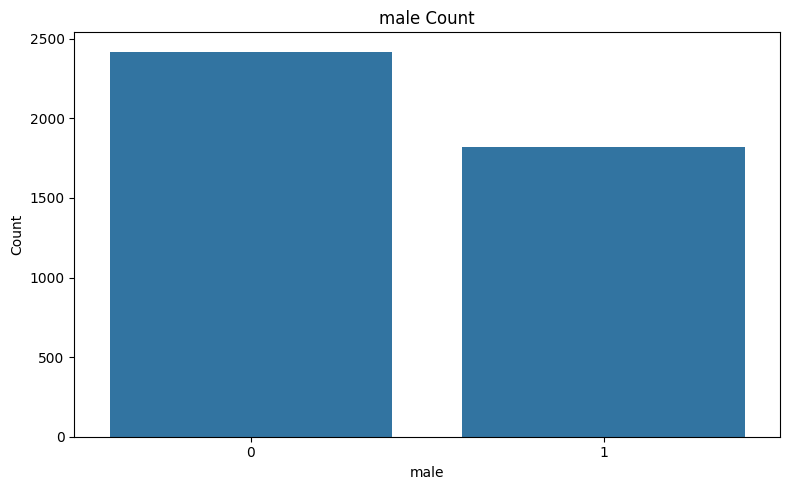

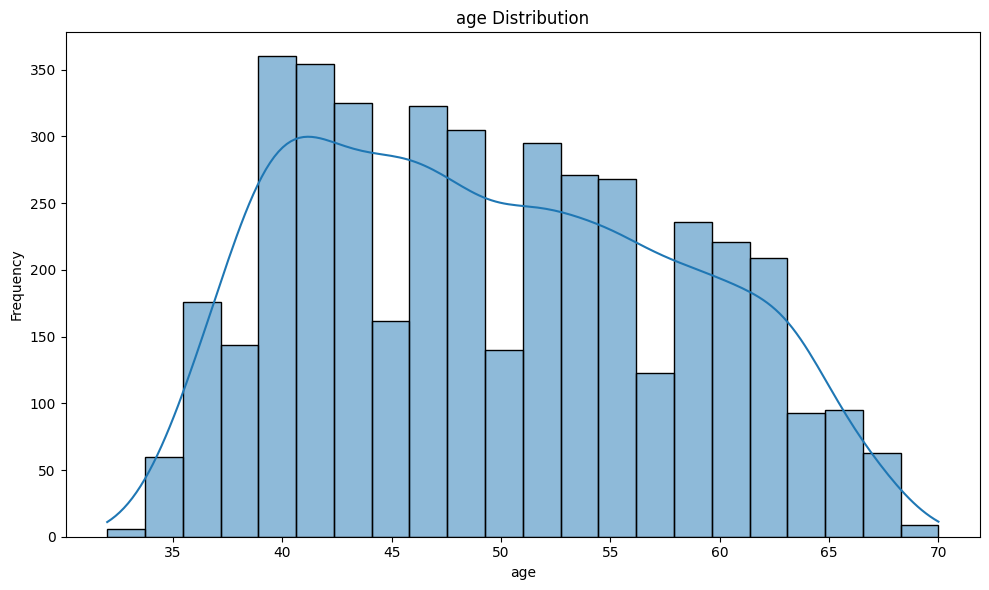

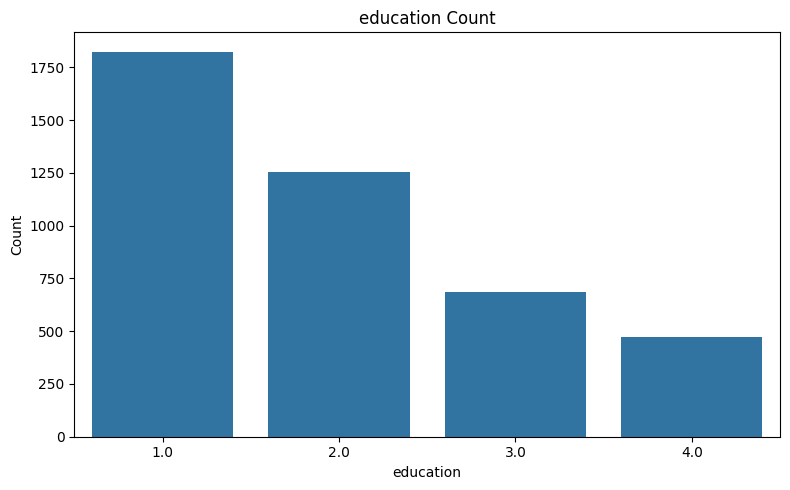

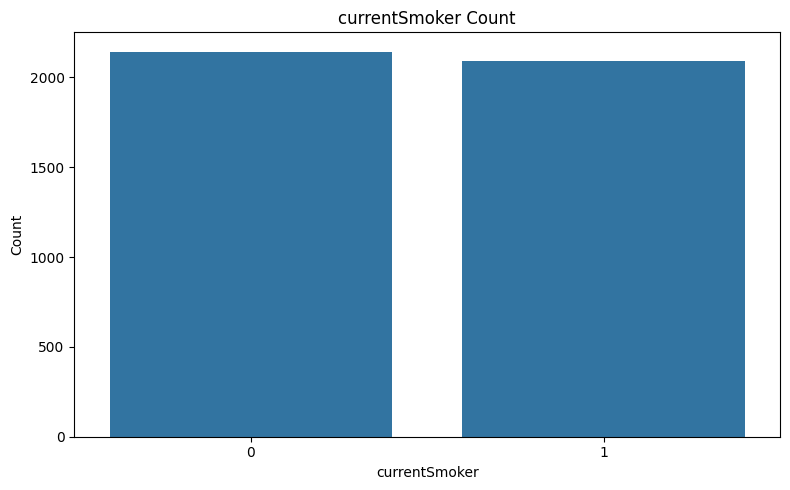

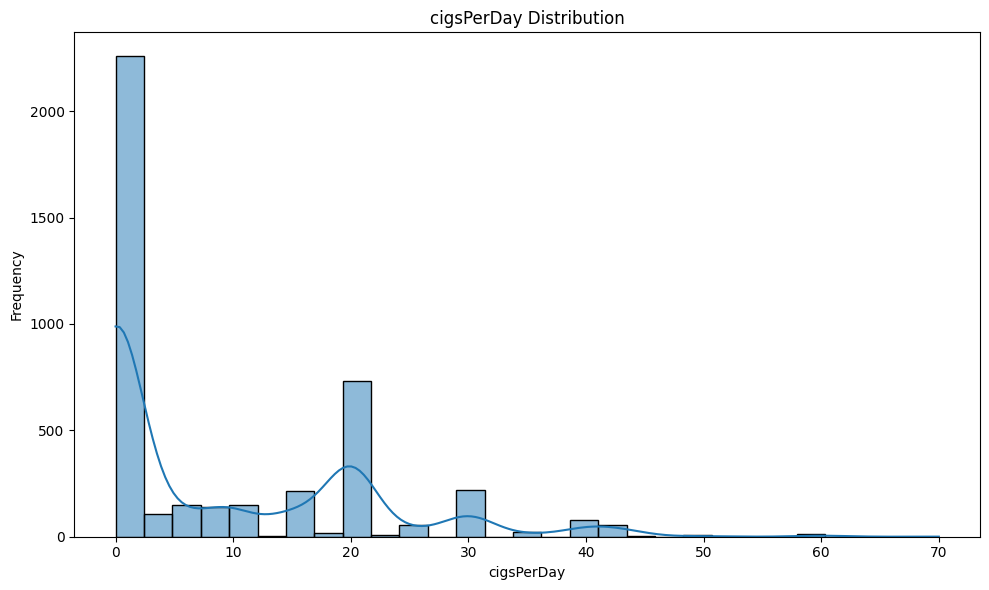

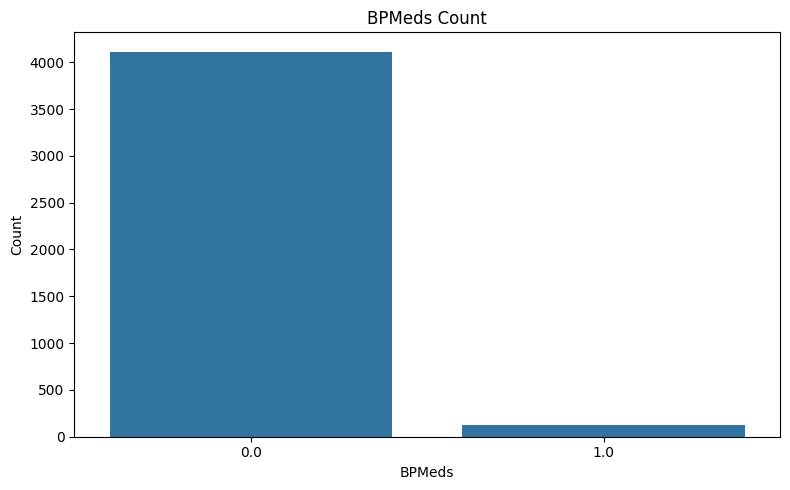

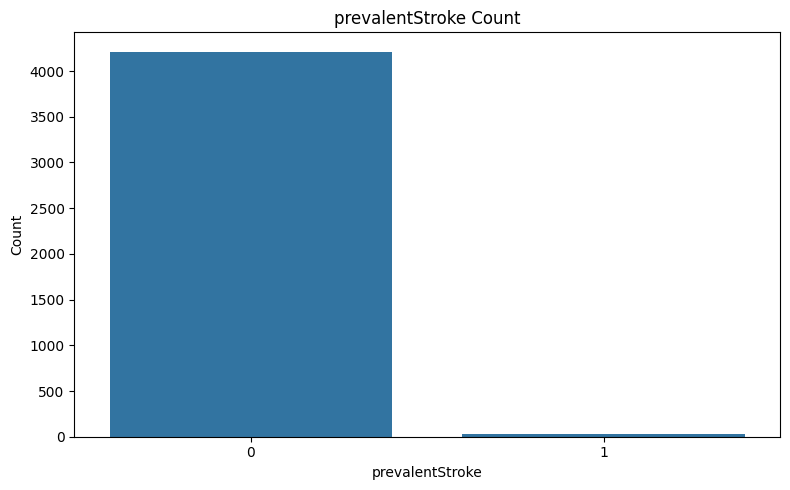

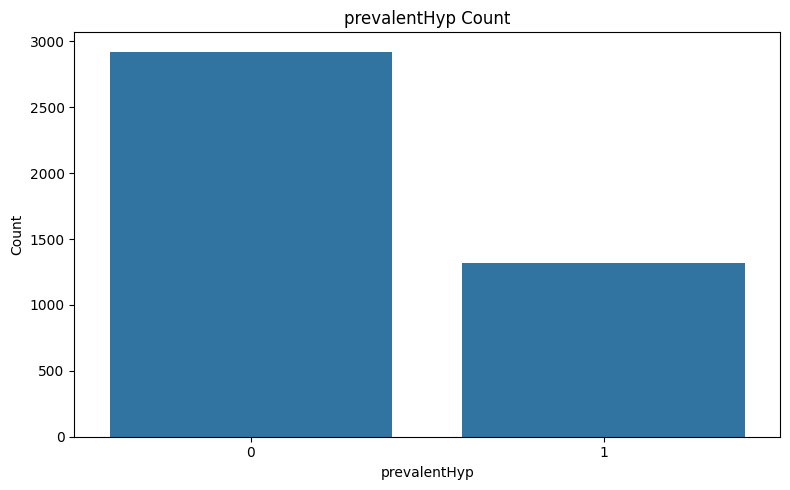

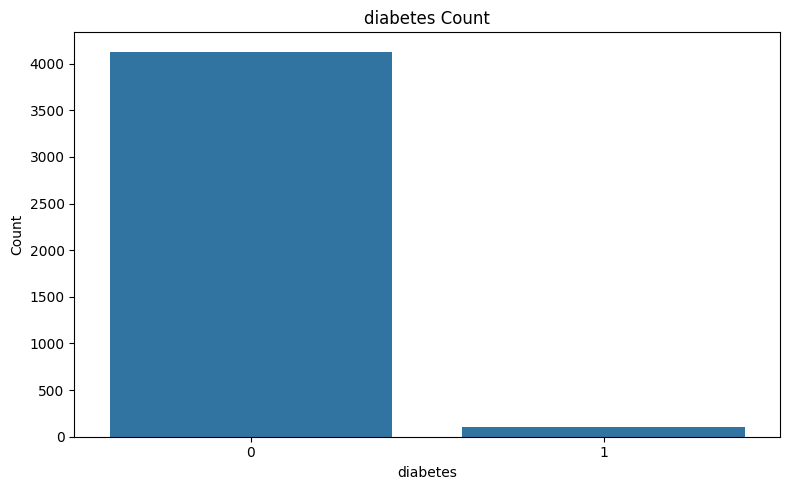

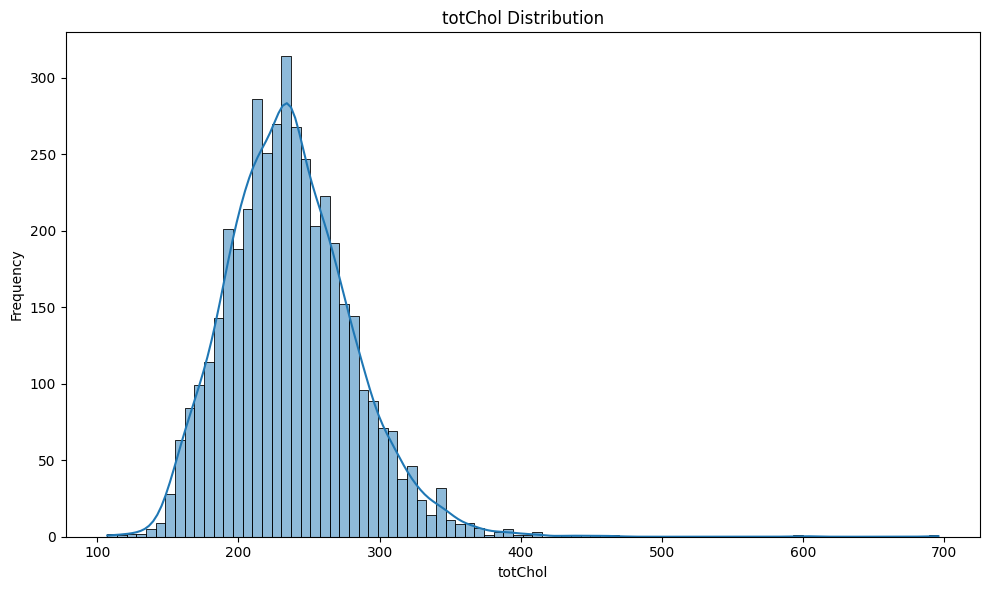

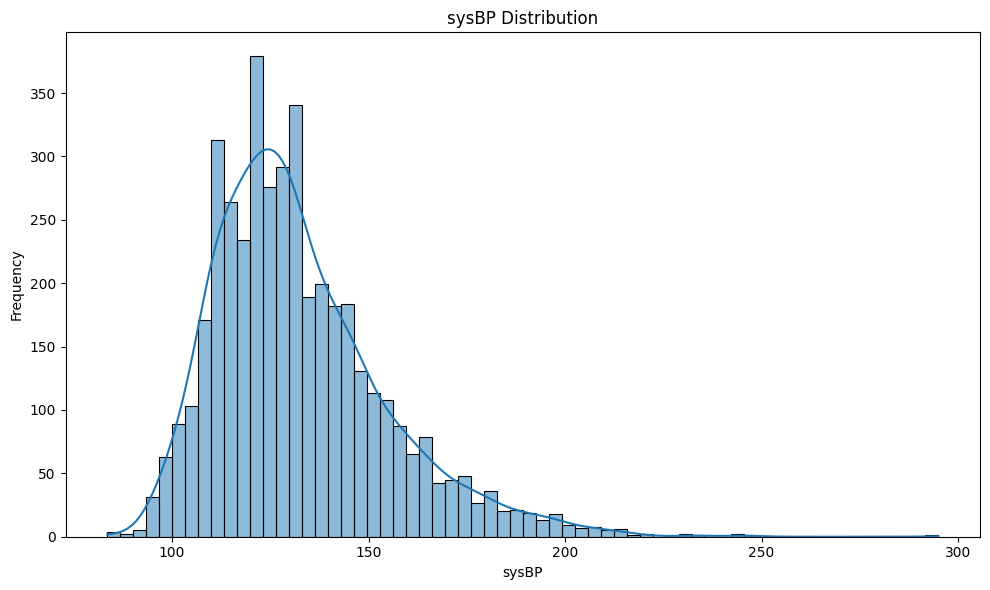

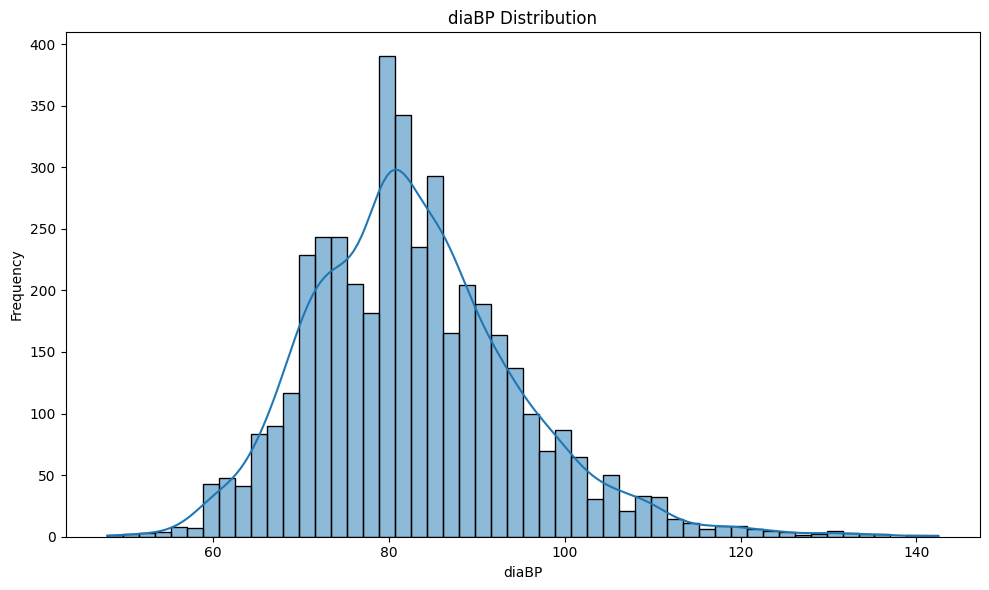

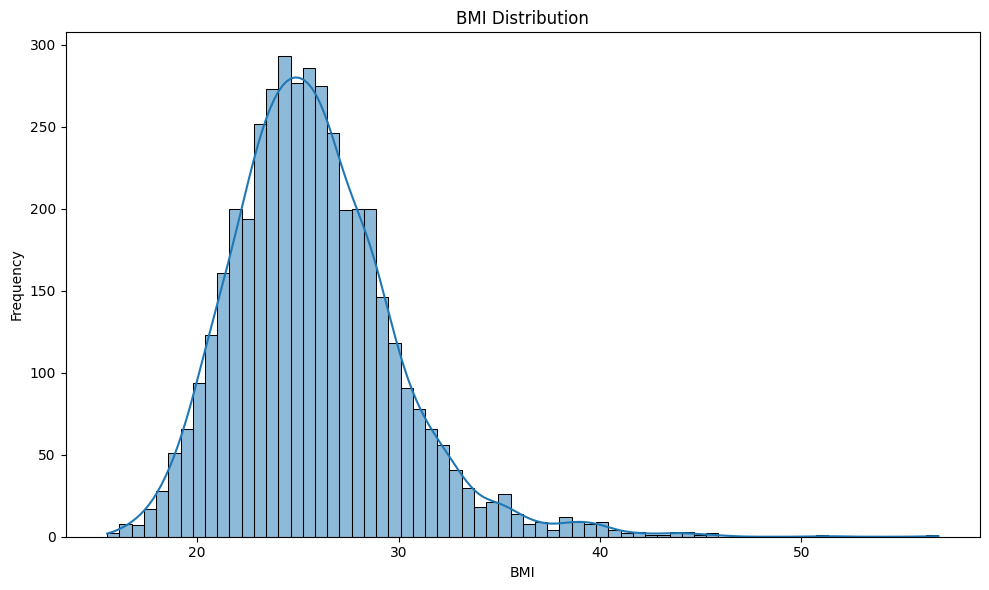

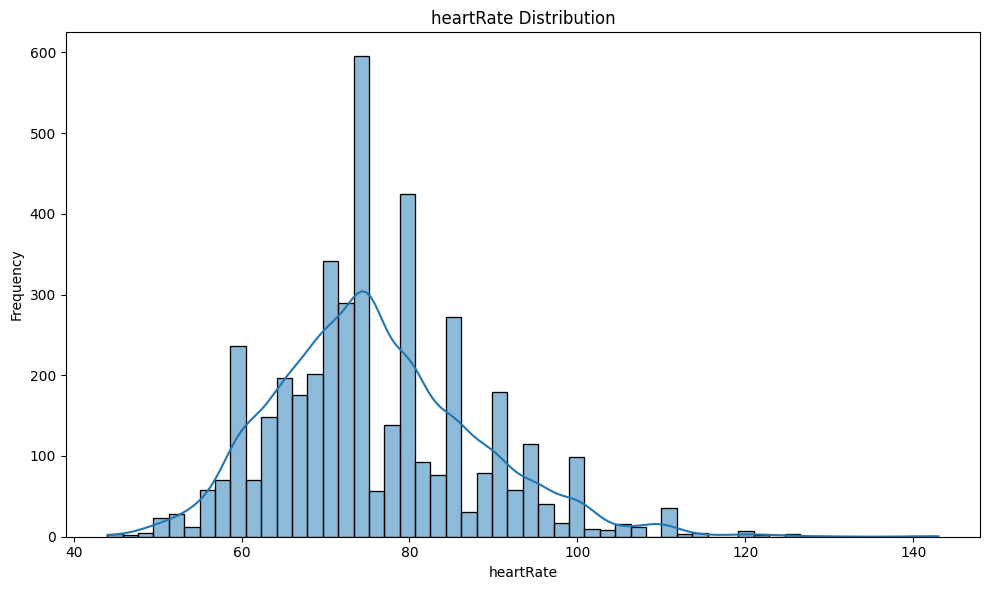

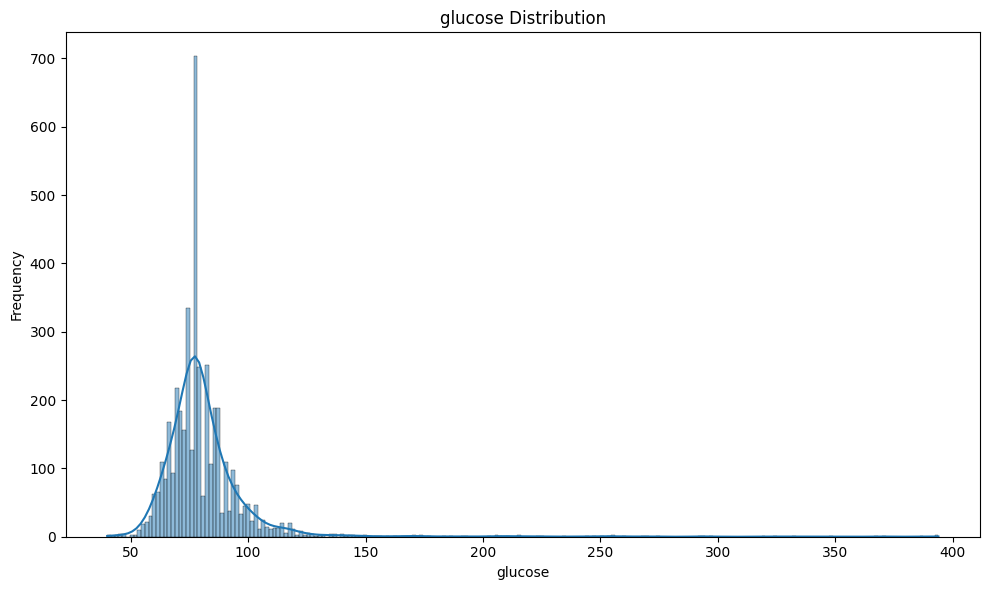

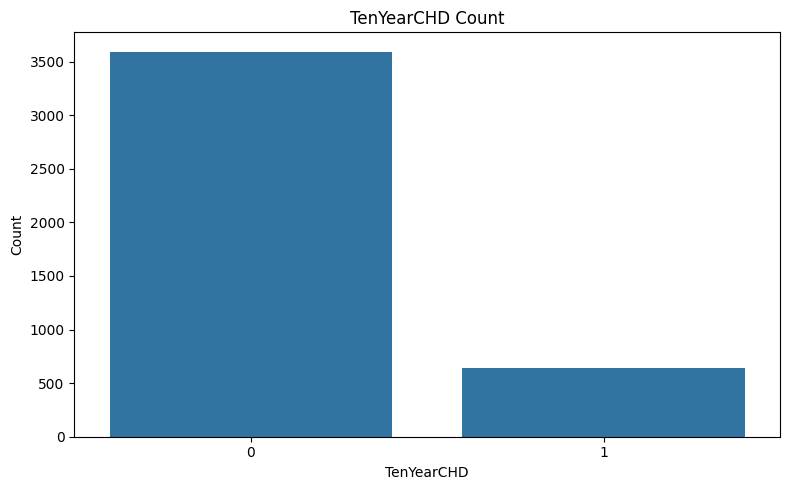

In [ ]:
categorical_cols = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']
numerical_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

for col in df.columns:
    if col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.histplot(df[col], kde=True)
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.title(f'{col} Distribution')
        plt.tight_layout()
        plt.show()
        plt.close()
    elif col in categorical_cols:
        plt.figure(figsize=(8, 5))
        sns.countplot(x=col, data=df)
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.title(f'{col} Count')
        plt.tight_layout()
        plt.show()
        plt.close()

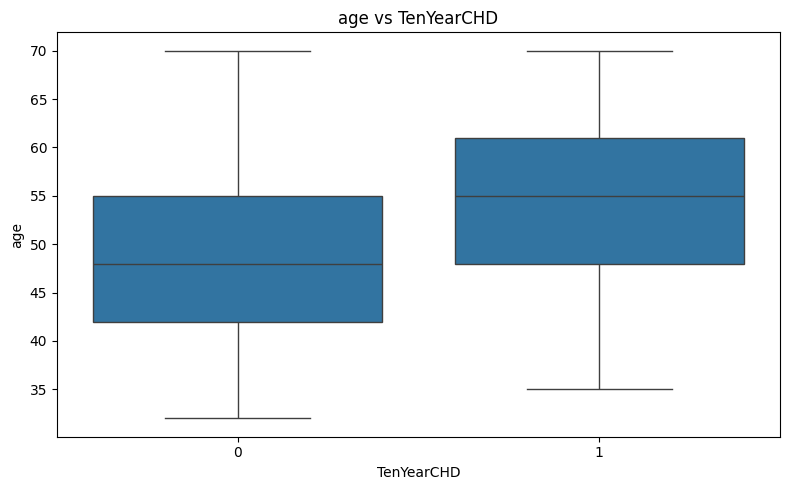

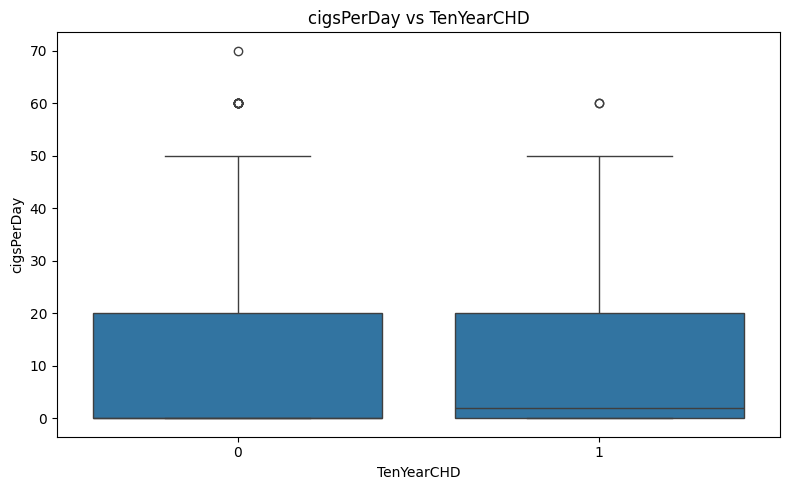

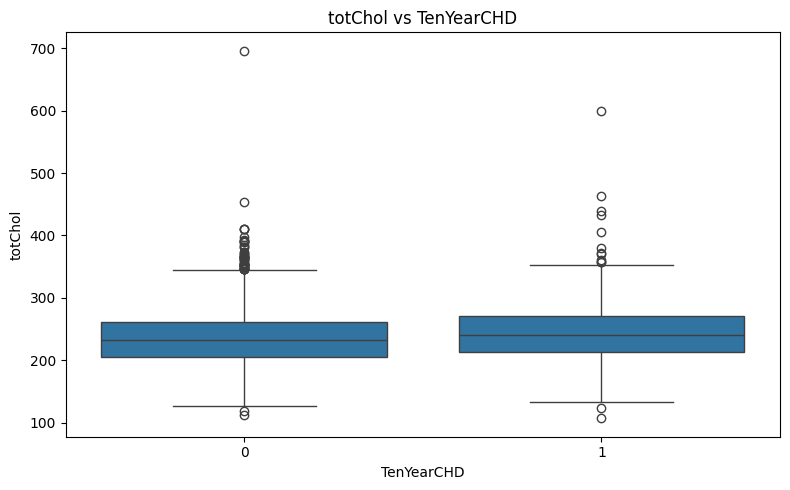

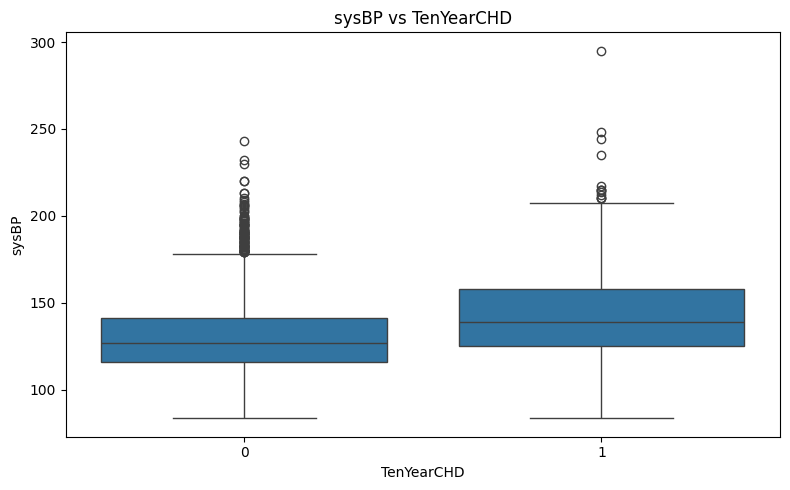

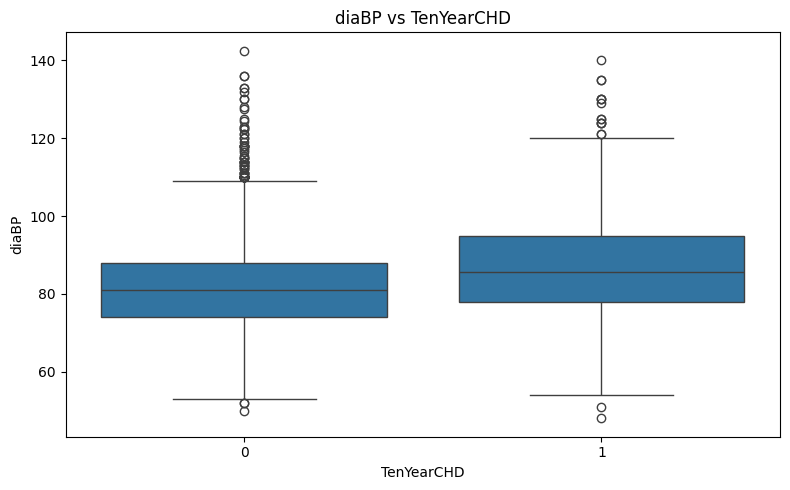

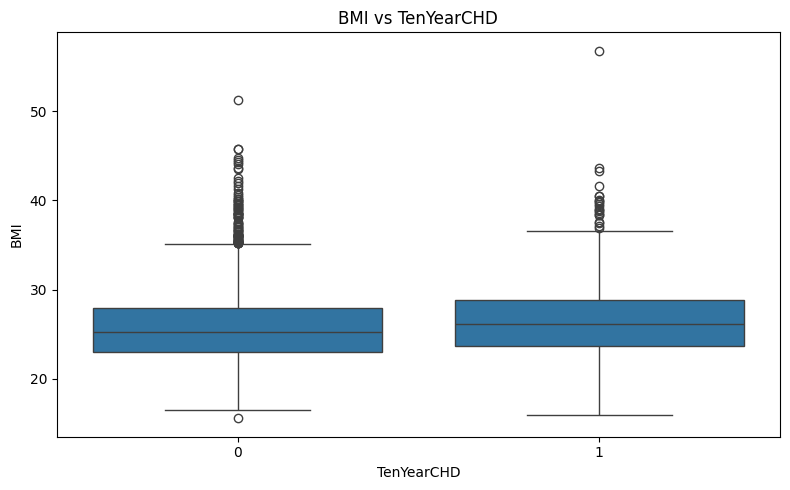

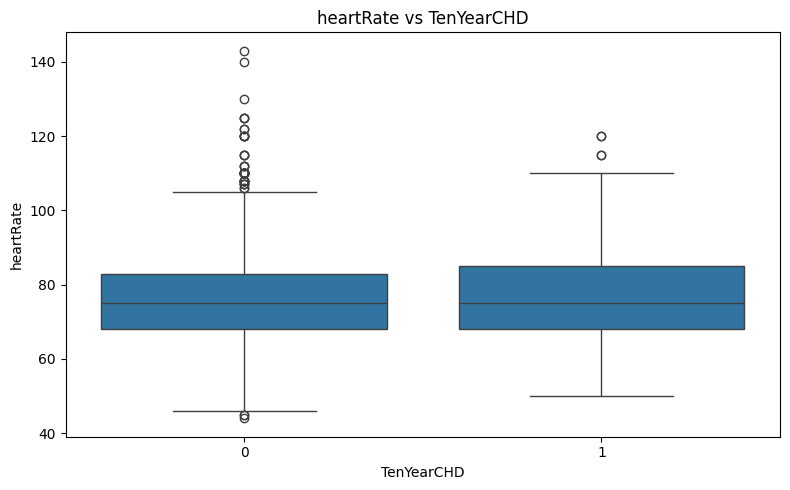

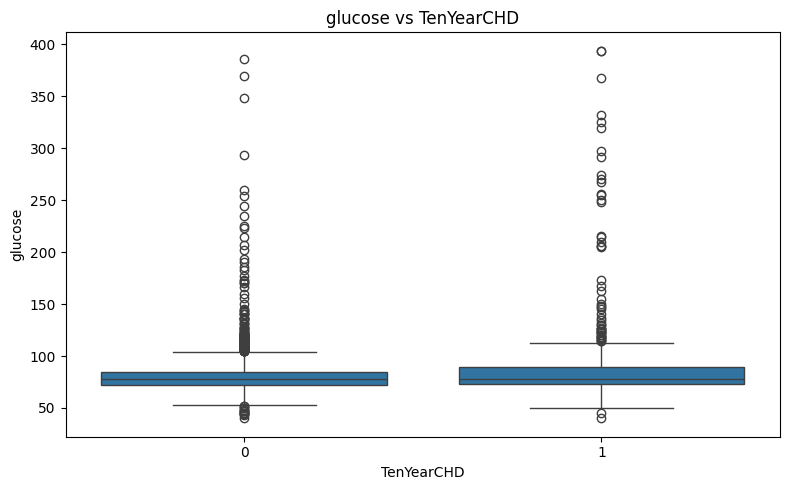

In [ ]:
numerical_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='TenYearCHD', y=col, data=df)
    plt.xlabel('TenYearCHD')
    plt.ylabel(col)
    plt.title(f'{col} vs TenYearCHD')
    plt.tight_layout()
    plt.show()
    plt.close()

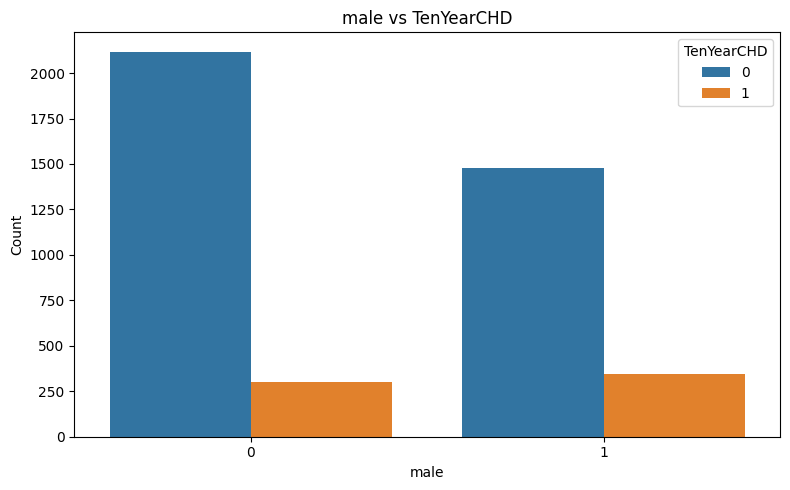

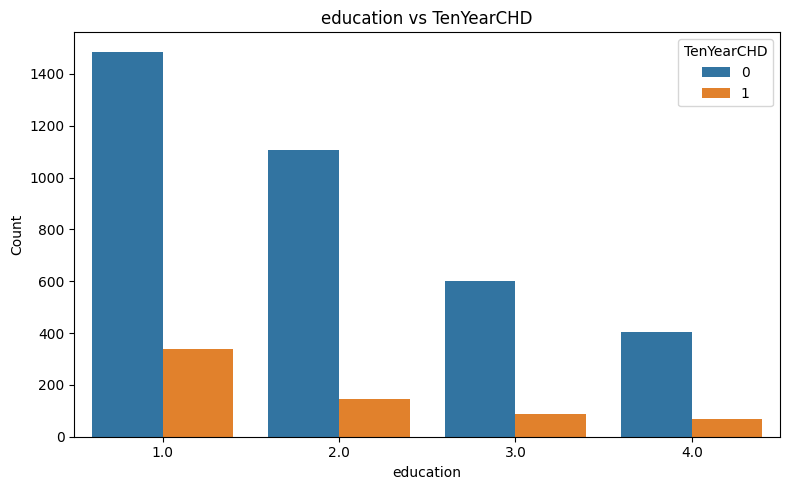

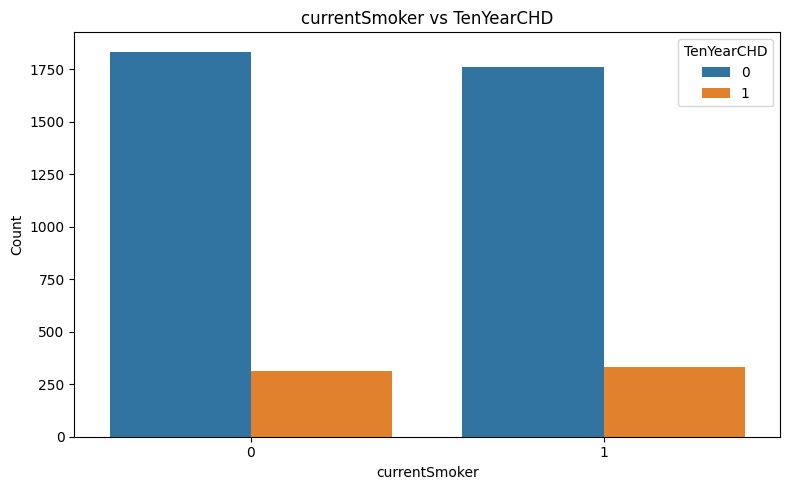

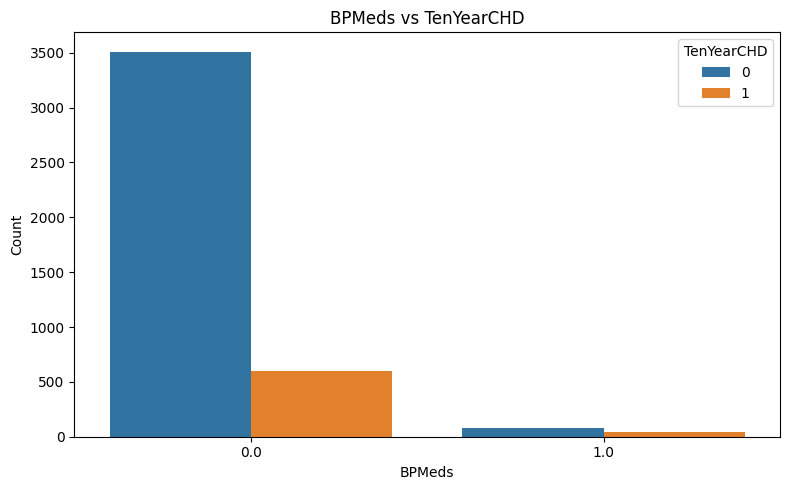

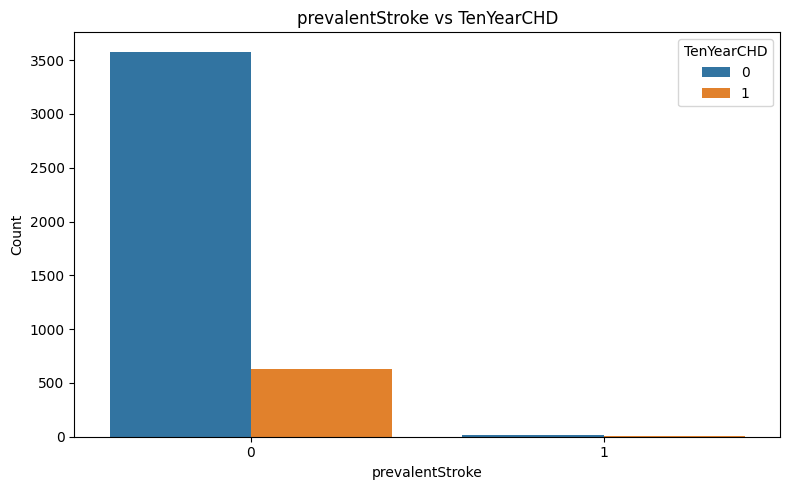

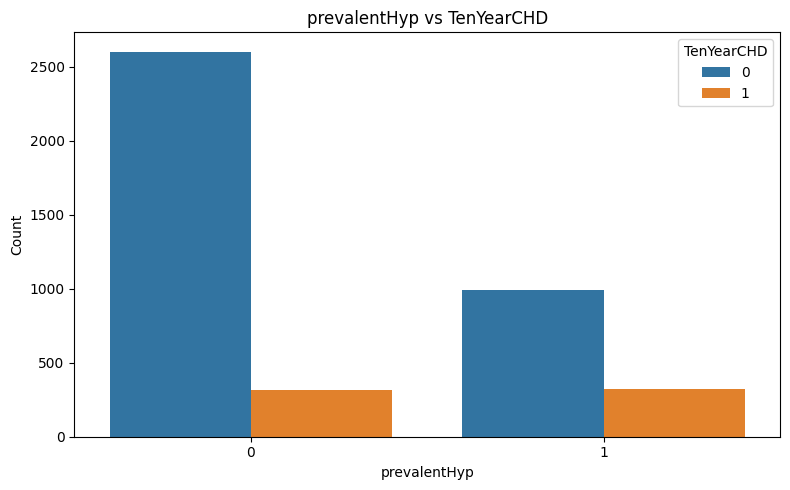

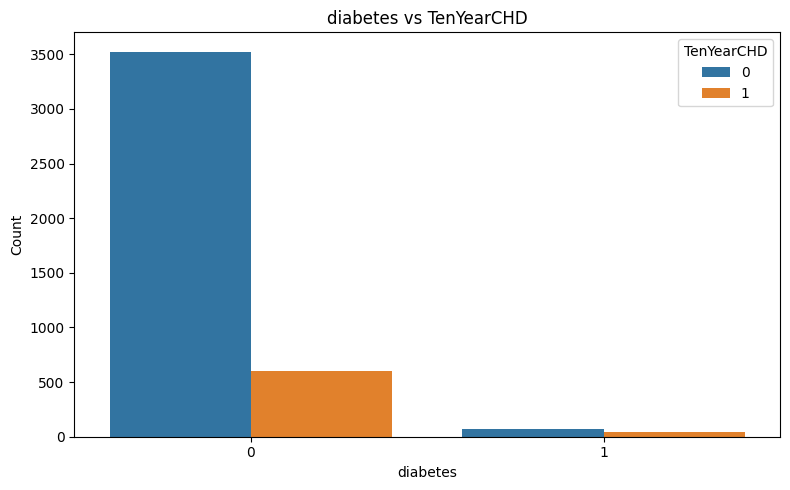

In [ ]:
categorical_cols = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, hue='TenYearCHD', data=df)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'{col} vs TenYearCHD')
    plt.tight_layout()
    plt.show()
    plt.close()

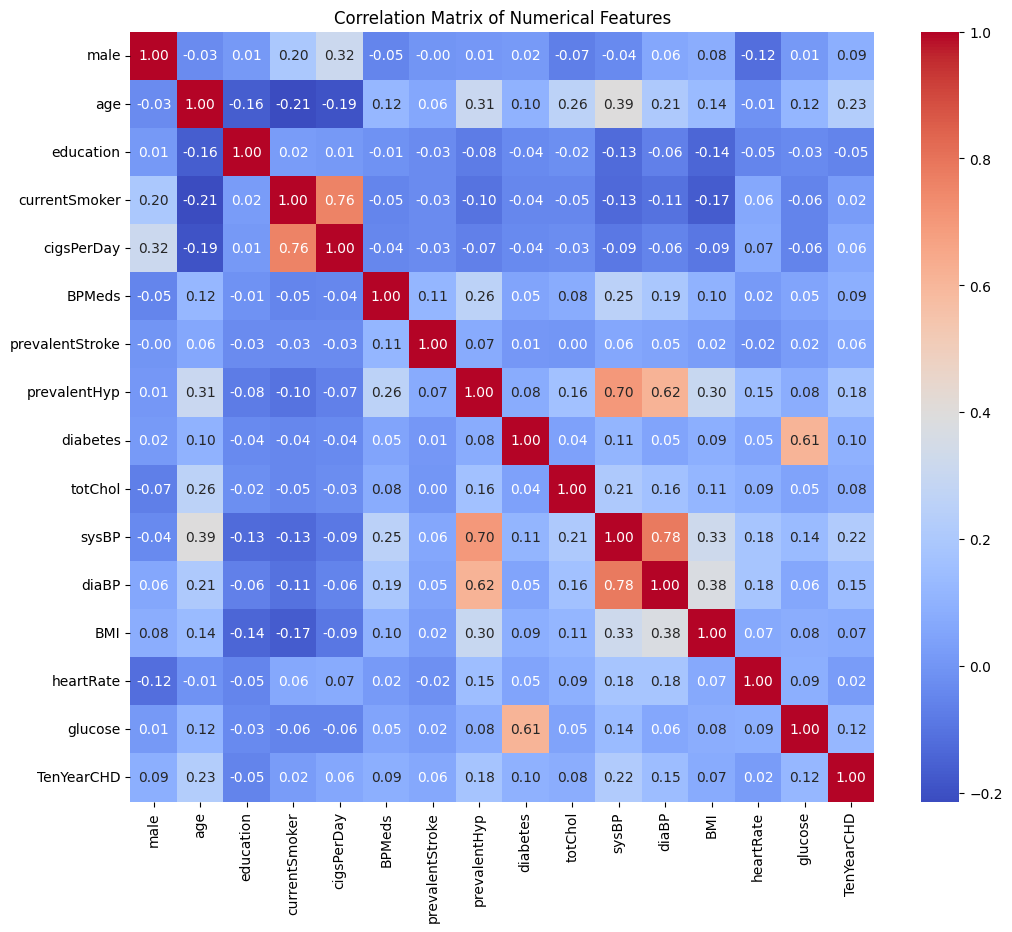

In [ ]:
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()
plt.close()

## Feature Importance (using a simple model)

### Subtask:
Determine which features have the most significant impact on the target variable using a scikit-learn model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

# Split data into training and testing sets (optional but good practice)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a simple model (RandomForestClassifier)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Get feature importances
feature_importance = pd.Series(model.feature_importances_, index=X.columns)

# Sort feature importances
sorted_feature_importance = feature_importance.sort_values(ascending=False)

# Display feature importances
print("Feature Importances:")
print(sorted_feature_importance)

Feature Importances:
sysBP              0.135145
BMI                0.127140
age                0.126798
totChol            0.122149
diaBP              0.117396
glucose            0.115589
heartRate          0.097381
cigsPerDay         0.051918
education          0.038311
male               0.019628
prevalentHyp       0.018459
currentSmoker      0.012691
BPMeds             0.007392
diabetes           0.006304
prevalentStroke    0.003698
dtype: float64


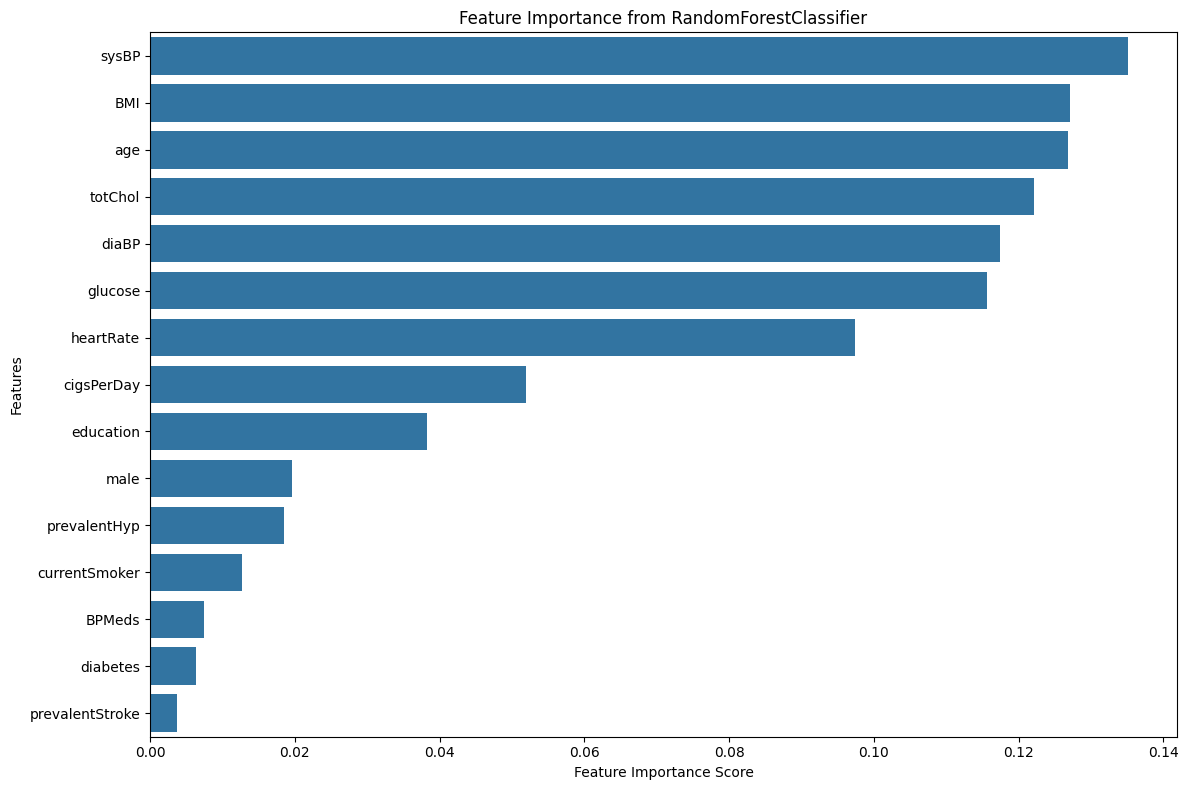

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_feature_importance, y=sorted_feature_importance.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance from RandomForestClassifier')
plt.tight_layout()
plt.show()
plt.close()

## EDA Insights

Here's a summary of what I found during my exploratory data analysis:

**Data Preprocessing & Cleaning:**
*   I handled the missing values by filling them with the mode or median, depending on the column type.
*   I didn't find any other major inconsistencies or errors.

**Univariate Analysis:**
*   Some numerical features (`age`, `sysBP`, `diaBP`) seem a bit skewed.
*   Categorical features like `male`, `currentSmoker`, `prevalentHyp`, and my target variable `TenYearCHD` have class imbalances. The imbalance in `TenYearCHD` is particularly noticeable.

**Bivariate Analysis:**
*   It looks like patients with a 10-year risk of CHD (`TenYearCHD=1`) tend to have higher values for `age`, `sysBP`, `diaBP`, `totChol`, and `glucose`.
*   The risk of CHD (`TenYearCHD=1`) seems more common in certain groups within the `male`, `currentSmoker`, `prevalentHyp`, and `diabetes` categories.

**Correlation Analysis:**
*   There are strong positive correlations between `sysBP` and `diaBP`, `currentSmoker` and `cigsPerDay`, and `age` with several other features (`sysBP`, `diaBP`, `totChol`, `prevalentHyp`).

**Feature Importance (from RandomForestClassifier):**
*   Based on the RandomForestClassifier model, the most important features for predicting `TenYearCHD` appear to be `sysBP`, `BMI`, `age`, `totChol`, `diaBP`, and `glucose`.
*   Features like `prevalentStroke`, `diabetes`, and `BPMeds` seemed less important in this model.

**Next Steps: Getting Data Ready for Modeling**
From this EDA, I have a better understanding of my data and how the features relate to the target. Before building my predictive model, I should think about:
*   Dealing with potential multicollinearity (like the strong correlation between `sysBP` and `diaBP`, or `currentSmoker` and `cigsPerDay`).
*   Considering the class imbalance in the target variable.
*   Scaling the numerical features, as some models are sensitive to the scale of the data.
*   Making a final decision on which features to include in my model, using the importance scores and my understanding of the data.

**Reasoning**:
Split the data into features (X) and target (y), initialize and train a RandomForestClassifier model, and then extract and display the feature importances.

## Train the Logistic Regression Model and Plot Loss

### Subtask:
Train the custom Logistic Regression model with normalized data and visualize the training loss.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select numerical columns
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Display the first few rows of the normalized training data
display(X_train.head())

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
3252,1.168617,-1.110334,2.028213,1.001771,1.764381,-0.173442,-0.078951,-0.675415,-0.16037,-0.715879,-0.062841,-0.165921,-0.510565,-0.837773,0.237178
3946,-0.855712,0.871963,0.054439,-0.998232,-0.755491,-0.173442,-0.078951,1.480571,-0.16037,0.295853,0.909287,0.795214,1.576245,-0.083421,0.546268
1261,-0.855712,-0.294094,-0.932448,-0.998232,-0.755491,-0.173442,-0.078951,-0.675415,-0.16037,-0.153806,-0.424563,-1.001691,0.278381,0.587114,-0.381003
2536,1.168617,-0.993728,0.054439,1.001771,1.764381,-0.173442,-0.078951,-0.675415,-0.16037,-0.198772,-0.876716,-0.040556,-0.040607,-0.753956,-0.513471
4089,-0.855712,1.688203,-0.932448,-0.998232,-0.755491,-0.173442,-0.078951,1.480571,-0.16037,-0.108840,0.773641,0.084810,-1.301945,-0.670139,0.634580


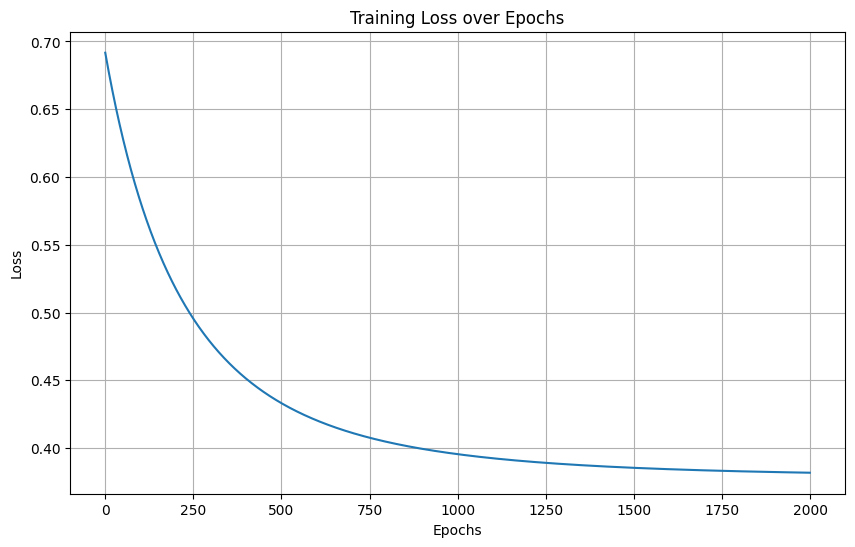

In [ ]:
# Initialize the Logistic Regression model
model = Logistic_Regression(learning_rate=0.01, epochs=2000) # Increased epochs for better visualization

# Train the model
model.fit(X_train, y_train)

# Plot the loss history
plt.figure(figsize=(10, 6))
plt.plot(range(model.epochs), model.loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()
plt.close()

Accuracy: 0.8573
Precision: 0.6154
Recall: 0.0645
F1 Score: 0.1168


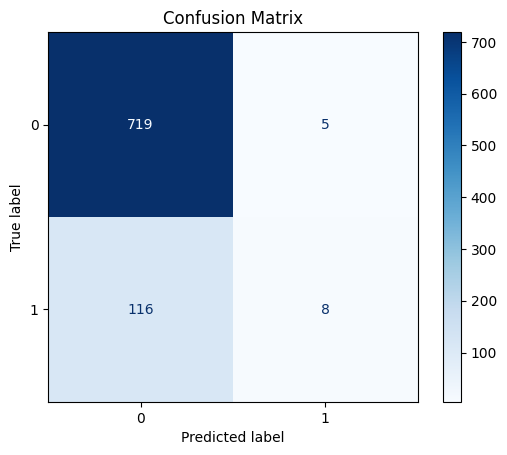

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on the normalized test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Generate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

## Model Evaluation Interpretation

The evaluation metrics and confusion matrix provide insights into the performance of the Logistic Regression model:

**Confusion Matrix:**

*   **True Positives (TP):** Instances where the model correctly predicted the positive class (`TenYearCHD = 1`). (Bottom-right cell)
*   **True Negatives (TN):** Instances where the model correctly predicted the negative class (`TenYearCHD = 0`). (Top-left cell)
*   **False Positives (FP):** Instances where the model incorrectly predicted the positive class (Type I error). (Top-right cell)
*   **False Negatives (FN):** Instances where the model incorrectly predicted the negative class (Type II error). (Bottom-left cell)

The confusion matrix shows a significant number of True Negatives (correctly predicting no CHD), which is expected given the class imbalance. However, there are many False Negatives (missing actual CHD cases) compared to True Positives.

**Evaluation Metrics:**

*   **Accuracy:** Overall proportion of correct predictions. Calculated as (TP + TN) / Total. Your accuracy is around **0.8573**, indicating the model is generally correct, but this can be misleading with imbalanced data.
*   **Precision:** Of all predicted positive instances, how many were actually positive? Calculated as TP / (TP + FP). Your precision is around **0.6154**, meaning when the model predicts CHD, it's correct about 61.54% of the time.
*   **Recall (Sensitivity):** Of all actual positive instances, how many were correctly predicted as positive? Calculated as TP / (TP + FN). Your recall is around **0.0645**, indicating the model only captured about 6.45% of the actual CHD cases. This is low and highlights the model's difficulty in identifying positive instances.
*   **F1 Score:** The harmonic mean of Precision and Recall, balancing both metrics. Calculated as 2 \* (Precision \* Recall) / (Precision + Recall). Your F1 score is around **0.1168**, a low value reflecting the poor recall and the challenge of the imbalanced dataset.

The low recall and F1 score suggest that while the model is good at identifying negative cases, it struggles to correctly identify patients who will develop TenYearCHD. This is a common issue with imbalanced datasets.

## Implement Logistic Regression Using scikit-learn

### Subtask:
Implement Logistic Regression using the scikit-learn library and train it on the normalized data.

**Reasoning**:
Import the `LogisticRegression` class from `sklearn.linear_model`. Initialize a `LogisticRegression` model. Train the model using the normalized training features (`X_train`) and target variable (`y_train`).

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the scikit-learn Logistic Regression model
# Using a solver that works well with the current data and potentially class_weight to handle imbalance
sklearn_model = LogisticRegression(solver='liblinear', random_state=42)

# Train the model on the normalized training data
sklearn_model.fit(X_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

## Evaluate scikit-learn Logistic Regression Model

### Subtask:
Evaluate the performance of the scikit-learn Logistic Regression model using accuracy, precision, recall, and F1-score.

**Reasoning**:
Use the trained `sklearn_model` to make predictions on the normalized test features (`X_test`). Calculate accuracy, precision, recall, and F1-score using the actual test labels (`y_test`) and the predicted labels (`y_pred_sklearn`). Print the calculated metrics.

Scikit-learn Model Evaluation Metrics:
Accuracy: 0.8573
Precision: 0.6000
Recall: 0.0726
F1 Score: 0.1295


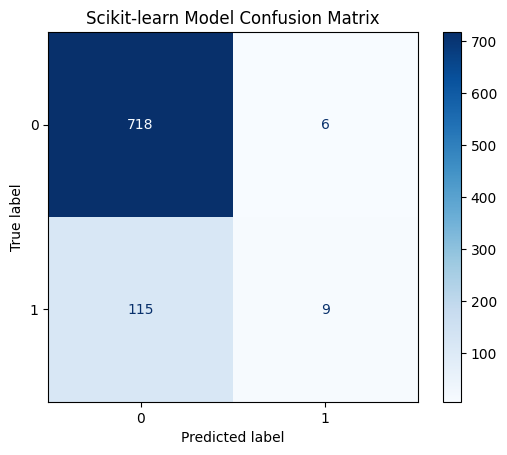

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on the normalized test set using the scikit-learn model
y_pred_sklearn = sklearn_model.predict(X_test)

# Calculate evaluation metrics for the scikit-learn model
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
precision_sklearn = precision_score(y_test, y_pred_sklearn)
recall_sklearn = recall_score(y_test, y_pred_sklearn)
f1_sklearn = f1_score(y_test, y_pred_sklearn)

# Display the metrics
print("Scikit-learn Model Evaluation Metrics:")
print(f"Accuracy: {accuracy_sklearn:.4f}")
print(f"Precision: {precision_sklearn:.4f}")
print(f"Recall: {recall_sklearn:.4f}")
print(f"F1 Score: {f1_sklearn:.4f}")

# Generate and display the confusion matrix for the scikit-learn model
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
disp_sklearn = ConfusionMatrixDisplay(confusion_matrix=cm_sklearn, display_labels=[0, 1])
disp_sklearn.plot(cmap=plt.cm.Blues)
plt.title('Scikit-learn Model Confusion Matrix')
plt.show()

In [ ]:
print("Comparison of Model Performance Metrics:")
print("-" * 40)
print("Custom Logistic Regression Model:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")
print("-" * 40)
print("Scikit-learn Logistic Regression Model:")
print(f"  Accuracy: {accuracy_sklearn:.4f}")
print(f"  Precision: {precision_sklearn:.4f}")
print(f"  Recall: {recall_sklearn:.4f}")
print(f"  F1 Score: {f1_sklearn:.4f}")
print("-" * 40)

Comparison of Model Performance Metrics:
----------------------------------------
Custom Logistic Regression Model:
  Accuracy: 0.8573
  Precision: 0.6154
  Recall: 0.0645
  F1 Score: 0.1168
----------------------------------------
Scikit-learn Logistic Regression Model:
  Accuracy: 0.8573
  Precision: 0.6000
  Recall: 0.0726
  F1 Score: 0.1295
----------------------------------------


## Comparison of My Custom vs. scikit-learn Logistic Regression Models

Based on the evaluation metrics and my experience building both models, here's a comparison:

**Performance Differences (Accuracy, Precision, Recall, F1-score):**

Looking at the metrics we printed out:
*   Both my custom model and the scikit-learn model ended up with pretty much the same **Accuracy** (around 0.8573). This isn't surprising since they're both trying to solve the same problem, but as I noted earlier, accuracy isn't the best measure when the data is imbalanced.
*   The **Precision** was also quite similar for both (my custom model: 0.6154, scikit-learn: 0.6000). This means when either model predicted the risk, they were correct about 60-61% of the time.
*   The **Recall** was low for both, but the scikit-learn model was slightly better (my custom model: 0.0645, scikit-learn: 0.0726). Both models struggled to find all the actual cases of risk, but the scikit-learn one caught a few more.
*   The **F1 Score**, which balances precision and recall, was also low for both, again with scikit-learn being slightly higher (my custom model: 0.1168, scikit-learn: 0.1295). This confirms that both models had difficulty with the minority class, but the scikit-learn one was marginally better.

Overall, the performance on this dataset was quite similar between my implementation and the scikit-learn one, with scikit-learn having a slight edge in recall and F1 score. This tells me that my custom implementation's core logic is on the right track.

**Training Time:**

Even though I didn't specifically time how long each model took to train, I know that libraries like scikit-learn are highly optimized. They use very efficient algorithms. My custom implementation, using basic gradient descent, would likely be much slower, especially if I had a much larger dataset. For real-world projects, scikit-learn would definitely be faster.

**Implementation Difficulty and Interpretability:**

*   **My Custom Implementation:** Building this from scratch was challenging! I had to really understand and write out the math for the sigmoid function, the loss function, and how to update the weights using gradient descent. It involved a lot more coding and debugging. However, the great thing is that I can see exactly what's happening at every step. It's completely transparent and highly interpretable because I built it myself.
*   **Scikit-learn Implementation:** This was so much easier! It only took a few lines of code to import the model, create it, and train it. All the complicated math and optimization are hidden behind simple functions like `.fit()` and `.predict()`. It's much quicker to get a model running, but it feels more like a "black box" compared to my custom one. I can still look at things like the learned coefficients, but I don't see the training process step-by-step.

**Conclusion:**

I successfully built a Logistic Regression model from scratch and compared it to the one in scikit-learn. I learned a lot about the internal workings of the algorithm by building it myself. The scikit-learn version was much easier and likely more efficient for practical use. Building from scratch is a valuable learning experience for understanding the fundamentals, while scikit-learn is the tool I'd use for most real-world tasks.